                            OLS Regression Results                            
Dep. Variable:         log_ai_patents   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     24.97
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.16e-06
Time:                        18:06:51   Log-Likelihood:                -1004.1
No. Observations:                 817   AIC:                             2012.
Df Residuals:                     815   BIC:                             2022.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9428      0.055     17.070      0.0

c:\Users\dbvan\miniforge3\envs\dsc80Fresh\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 37, but rank is 35
  warnings.warn('covariance of constraints does not have full '
c:\Users\dbvan\miniforge3\envs\dsc80Fresh\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 38, but rank is 36
  warnings.warn('covariance of constraints does not have full '
c:\Users\dbvan\miniforge3\envs\dsc80Fresh\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 250, but rank is 21
  warnings.warn('covariance of constraints does not have full '



                    Baseline Controls Industry-Year FE Nonlinear Firm FE Nonlinear
----------------------------------------------------------------------------------
Intercept           0.943*** 0.843*** -0.301           0.209     0.949***         
                    (0.055)  (0.099)  (0.500)          (0.496)   (0.322)          
log_emp             0.147*** 0.180*** 0.235***                                    
                    (0.029)  (0.030)  (0.042)                                     
rd_intensity                 0.221*** 0.218***         0.074     -0.076           
                             (0.082)  (0.081)          (0.056)   (0.191)          
capital_intensity            -0.920*  -0.784           -1.099**  1.303            
                             (0.539)  (0.510)          (0.519)   (1.550)          
capx_intensity               3.309    3.426            3.980     -4.585*          
                             (3.018)  (2.661)          (2.645)   (2.364)          
C(n

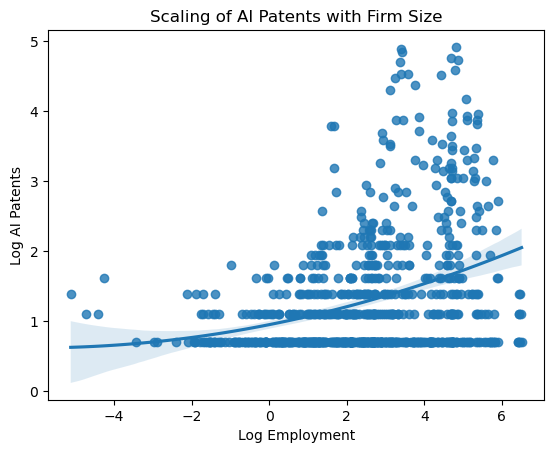

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)


df = pd.read_csv("FINAL CSV-AIP 197.csv")

df["datadate"] = pd.to_datetime(df["datadate"])

#basic drops

df = df.dropna(subset=["emp","revt","ppent","at"])

df["xrd"] = df["xrd"].fillna(0)

df = df[(df["emp"] > 0) & (df["revt"] > 0) & (df["at"] > 0)]

#log clarifications

df["log_emp"] = np.log(df["emp"])
df["log_assets"] = np.log(df["at"])
df["log_revenue"] = np.log(df["revt"])

df["log_ai_patents"] = np.log1p(df["ai_patent_count"])

#intesnity clarifications

df["rd_intensity"] = df["xrd"] / df["revt"]
df["capital_intensity"] = df["ppent"] / df["at"]
df["capx_intensity"] = df["capx"] / df["at"]

#winsor

for col in ["rd_intensity","capital_intensity","capx_intensity"]:
    
    lower = df[col].quantile(.01)
    upper = df[col].quantile(.99)
    
    df[col] = df[col].clip(lower, upper)


df["naics2"] = df["naics"].astype(str).str[:2]

#dropna

df = df.dropna(subset=[
    "log_emp",
    "log_ai_patents",
    "rd_intensity",
    "capital_intensity",
    "capx_intensity"
])

#OLS

model1 = smf.ols(
    "log_ai_patents ~ log_emp",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(model1.summary())

#OLS V2

model2 = smf.ols(
    "log_ai_patents ~ log_emp + rd_intensity + capital_intensity + capx_intensity",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(model2.summary())

#VIF

X = df[["log_emp","rd_intensity","capital_intensity","capx_intensity"]]

X = sm.add_constant(X)

vif = pd.DataFrame()

vif["variable"] = X.columns

vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

#industry and year fixed effects

model3 = smf.ols(
    "log_ai_patents ~ log_emp + rd_intensity + capital_intensity + capx_intensity + C(naics2) + C(fyear)",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(model3.summary())

#centered model

df["log_emp_centered"] = df["log_emp"] - df["log_emp"].mean()
df["log_emp_centered_sq"] = df["log_emp_centered"] ** 2

model4 = smf.ols(
    "log_ai_patents ~ log_emp_centered + log_emp_centered_sq + rd_intensity + capital_intensity + capx_intensity + C(naics2) + C(fyear)",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(model4.summary())

#FE 

model_fe = smf.ols(
    "log_ai_patents ~ log_emp_centered + log_emp_centered_sq + rd_intensity + capital_intensity + capx_intensity + C(gvkey) + C(fyear)",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(model_fe.summary())

#elasticity at mean firm size

elasticity_mean = model4.params["log_emp_centered"]

print("Elasticity at Mean Firm Size:", elasticity_mean)

#poisson model

poisson_model = smf.glm(
    "ai_patent_count ~ log_emp + rd_intensity + capital_intensity + capx_intensity + C(naics2) + C(fyear)",
    data=df,
    family=sm.families.Poisson()
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(poisson_model.summary())


#Regression table


summary = summary_col(
    [model1, model2, model3, model4, model_fe],
    stars=True,
    float_format="%0.3f",
    model_names=["Baseline","Controls","Industry-Year FE","Nonlinear","Firm FE Nonlinear"],
    info_dict={
        "N":lambda x: f"{int(x.nobs)}",
        "R2":lambda x: f"{x.rsquared:.3f}"
    }
)

print(summary)



#plot

import seaborn as sns

sns.regplot(x="log_emp", y="log_ai_patents", data=df, order=2)

plt.title("Scaling of AI Patents with Firm Size")
plt.xlabel("Log Employment")
plt.ylabel("Log AI Patents")

plt.show()

In [9]:
# industry total employment by industry-year
df["industry_emp"] = df.groupby(["naics2","fyear"])["emp"].transform("sum")

# lag industry employment within each industry
df["industry_emp_lag"] = df.groupby("naics2")["industry_emp"].shift(1)

# log transform
df["log_industry_emp_lag"] = np.log(df["industry_emp_lag"])

# drop rows where lag is missing
df = df.dropna(subset=["log_industry_emp_lag"])
from linearmodels.iv import IV2SLS

iv_model = IV2SLS.from_formula(
"log_ai_patents ~ 1 + rd_intensity + capital_intensity + capx_intensity + [log_emp ~ log_industry_emp_lag]",
data=df
).fit(cov_type="clustered", clusters=df["gvkey"])
print(iv_model.first_stage)
print(iv_model.summary)
print(df[["industry_emp","industry_emp_lag","log_industry_emp_lag"]].head())

    First Stage Estimation Results    
                               log_emp
--------------------------------------
R-squared                       0.2983
Partial R-squared               0.0091
Shea's R-squared                0.0091
Partial F-statistic             2.3756
P-value (Partial F-stat)        0.1232
Partial F-stat Distn           chi2(1)
========================== ===========
Intercept                       1.5128
                              (3.1185)
rd_intensity                   -1.6461
                             (-7.0416)
capital_intensity               3.4627
                              (1.8600)
capx_intensity                  4.2953
                              (0.6504)
log_industry_emp_lag            0.1139
                              (1.5413)
--------------------------------------

T-stats reported in parentheses
T-stats use same covariance type as original model
                          IV-2SLS Estimation Summary                          
Dep. Variable:    

In [ ]:
#Poisson Regression Coefficients Table
poisson_coef = poisson_model.params
poisson_se = poisson_model.bse

#significance
def sig_stars(pval):
    if pval < 0.01:
        return "***"
    elif pval < 0.05:
        return "**"
    elif pval < 0.1:
        return "*"
    else:
        return ""
poisson_pvals = poisson_model.pvalues
stars = [sig_stars(p) for p in poisson_pvals]

# df
poisson_table = pd.DataFrame({
    "Coefficient": poisson_coef,
    "Std. Error": poisson_se,
    "Significance": stars
})

# keys
poisson_table_main = poisson_table.loc[["log_emp","rd_intensity","capital_intensity","capx_intensity"]]

print("\nPoisson Regression Table (Selected Variables):")
print(poisson_table_main)


Poisson Regression Table (Selected Variables):
                   Coefficient  Std. Error Significance
log_emp                  0.621       0.085          ***
rd_intensity             0.684       0.172          ***
capital_intensity       -0.741       1.413             
capx_intensity           6.176       4.036             
